In [41]:
#importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
#loading files
df = pd.read_csv("cybersecurity_intrusion_data.csv")

In [43]:
#viewing the top 5 row
df.head(5)

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [44]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [45]:
df.describe() ##statistical description of the data

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [46]:
df.nunique() ## checking for unique value

session_id             9537
network_packet_size     959
protocol_type             3
login_attempts           13
session_duration       9532
encryption_used           2
ip_reputation_score    9537
failed_logins             6
browser_type              5
unusual_time_access       2
attack_detected           2
dtype: int64

In [47]:
mask = df.isna().sum()
mask

session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

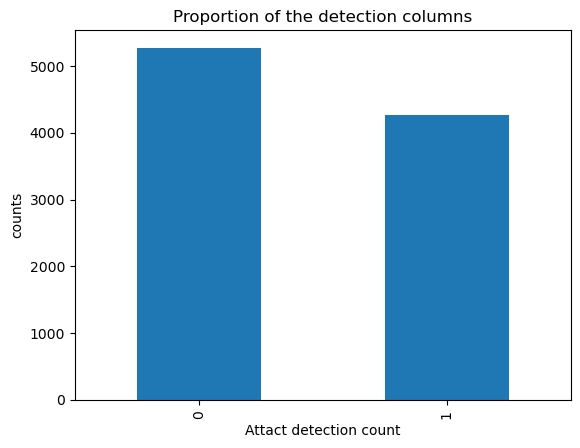

In [201]:
df["attack_detected"].value_counts().plot(kind="bar")
plt.xlabel("Attact detection count")
plt.ylabel("counts")
plt.title("Proportion of the detection columns");

In [202]:
## because of outliers we had to log and also the log are better for variance 
df["session_duration_log"]=np.log1p(df["session_duration"])

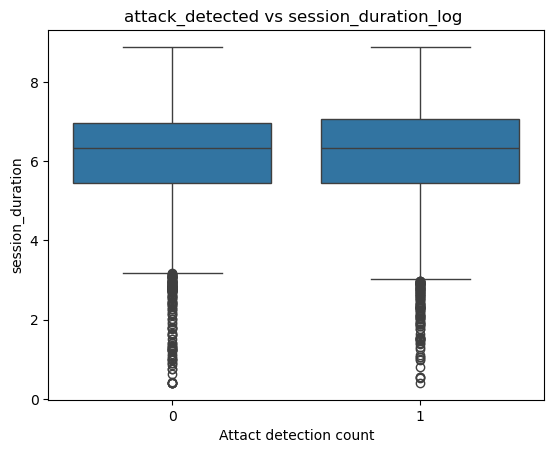

In [203]:
sns.boxplot(x =df["attack_detected"], y= df["session_duration_log"])
plt.xlabel("Attact detection count")
plt.ylabel("session_duration")
plt.title("attack_detected vs session_duration_log ");

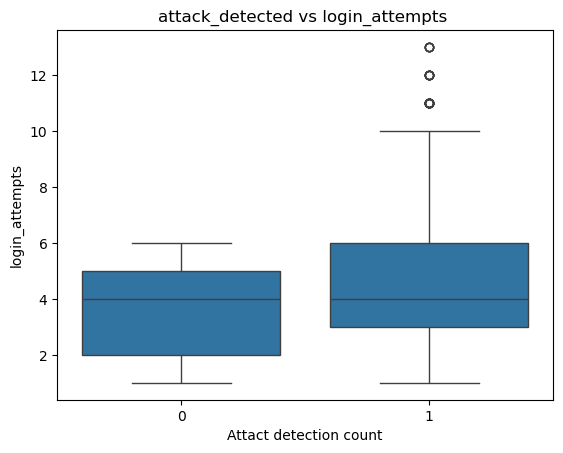

In [204]:
sns.boxplot(x=df['attack_detected'],y=df["login_attempts"] )
plt.xlabel("Attact detection count")
plt.ylabel("login_attempts")
plt.title("attack_detected vs login_attempts ");

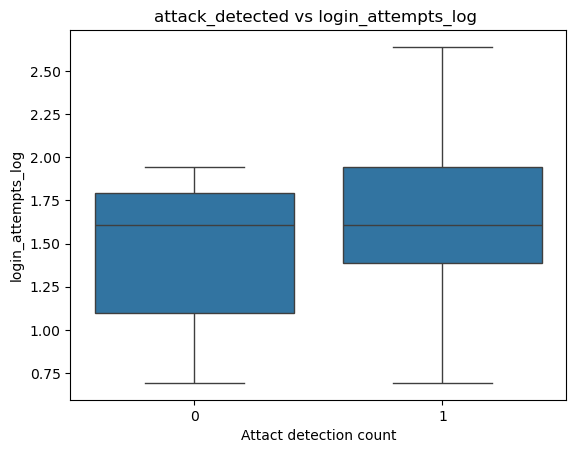

In [205]:
## because of outliers we had to log and als0 the log are better for variance
df["login_attempts_log"] = np.log1p(df["login_attempts"])
sns.boxplot(x=df['attack_detected'],y=df["login_attempts_log"] )
plt.xlabel("Attact detection count")
plt.ylabel("login_attempts_log")
plt.title("attack_detected vs login_attempts_log ");

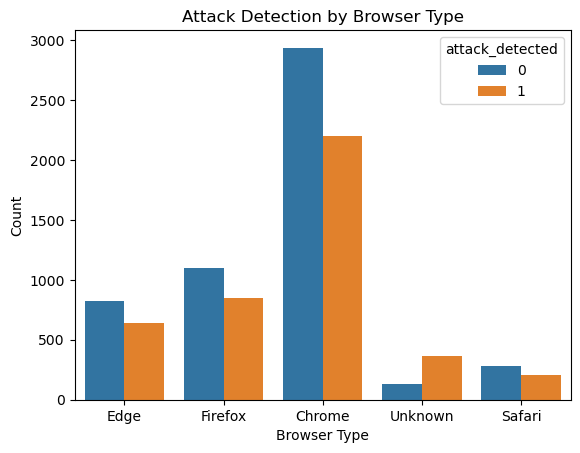

In [206]:
sns.countplot(x='browser_type', hue=df['attack_detected'], data=df)
plt.xlabel("Browser Type")
plt.ylabel("Count")
plt.title("Attack Detection by Browser Type");

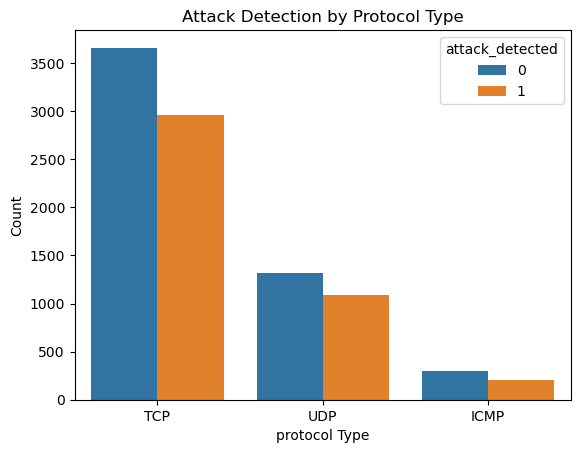

In [207]:

sns.countplot(x='protocol_type', hue=df['attack_detected'], data=df)
plt.xlabel("protocol Type")
plt.ylabel("Count")
plt.title("Attack Detection by Protocol Type");

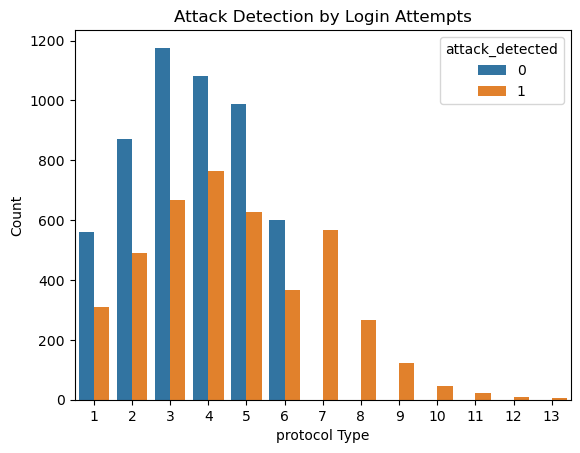

In [208]:
sns.countplot(x='login_attempts', hue=df['attack_detected'], data=df)
plt.xlabel("protocol Type")
plt.ylabel("Count")
plt.title("Attack Detection by Login Attempts");

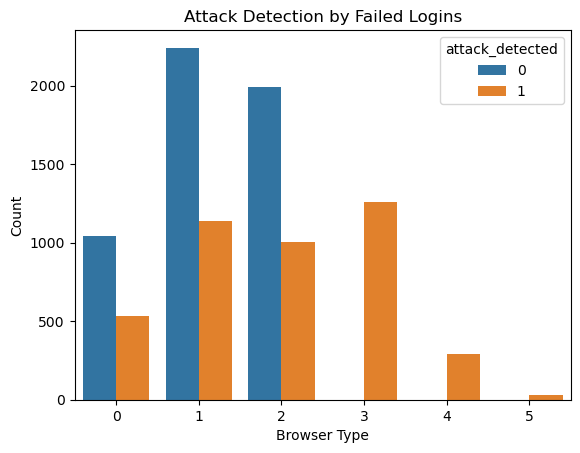

In [209]:

sns.countplot(x='failed_logins', hue=df['attack_detected'], data=df)
plt.xlabel("Browser Type")
plt.ylabel("Count")
plt.title("Attack Detection by Failed Logins");

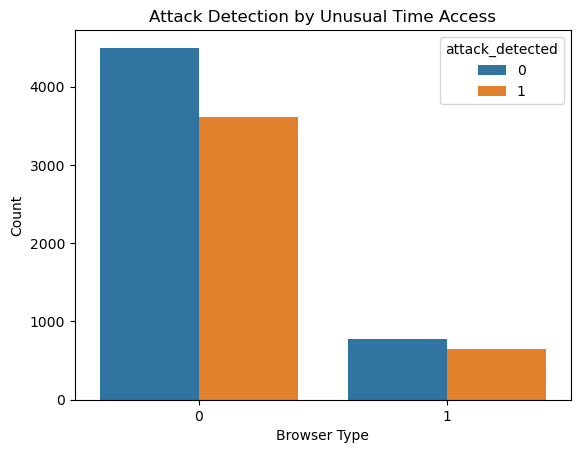

In [210]:
sns.countplot(x='unusual_time_access', hue=df['attack_detected'], data=df)
plt.xlabel("Browser Type")
plt.ylabel("Count")
plt.title("Attack Detection by Unusual Time Access");

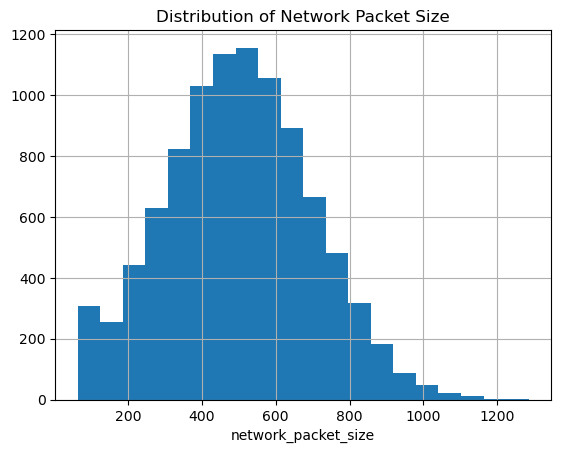

In [211]:
df['network_packet_size'].hist(bins=20)
plt.xlabel("network_packet_size")
plt.title("Distribution of Network Packet Size");

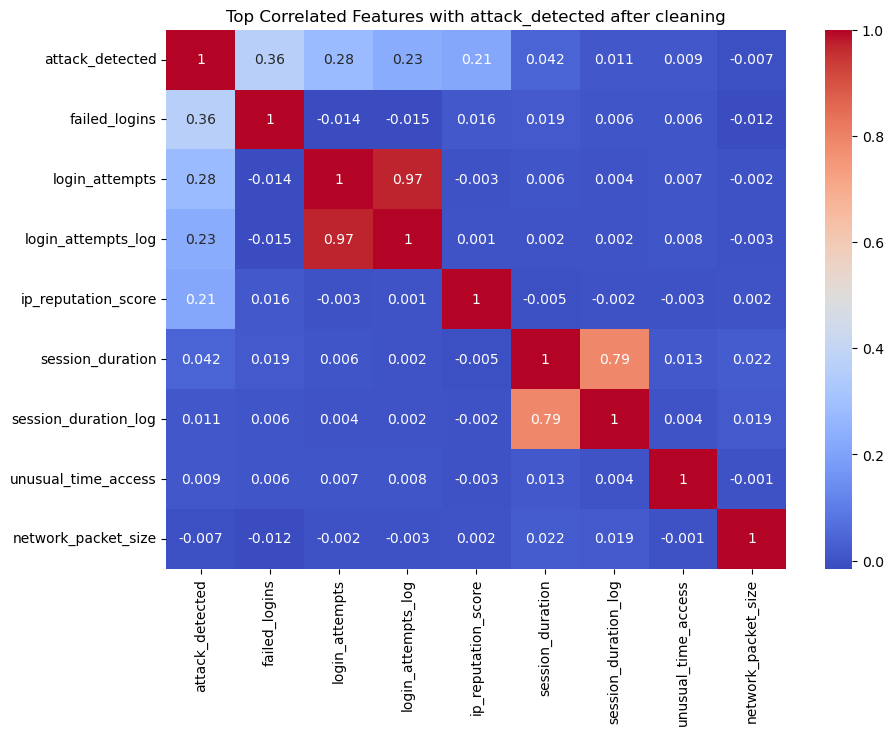

In [212]:
matrix=df.select_dtypes("number").columns
corr = df[matrix].corr().round(3)
top_features = corr[["attack_detected"]].abs().sort_values(by="attack_detected", ascending=False)
plt.figure(figsize=(10, 7))
sns.heatmap(corr[top_features.index].loc[top_features.index], annot=True, cmap='coolwarm')
plt.title("Top Correlated Features with attack_detected after cleaning")
plt.show()

In [243]:
from sklearn.model_selection import train_test_split,  RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [214]:
df.columns

Index(['session_id', 'network_packet_size', 'protocol_type', 'login_attempts',
       'session_duration', 'encryption_used', 'ip_reputation_score',
       'failed_logins', 'browser_type', 'unusual_time_access',
       'attack_detected', 'session_duration_log', 'login_attempts_log'],
      dtype='object')

In [215]:
## we drop the initial columsn because the log are better for variance
## we also seperated the features from the target variable
X = df.drop(columns = ["attack_detected", "session_id", "session_duration", "login_attempts"])
y = df['attack_detected']

In [216]:
baseline = y.value_counts(normalize=True)
baseline ### our data is slightly balanced

attack_detected
0    0.552899
1    0.447101
Name: proportion, dtype: float64

In [217]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2)

In [218]:
categorical = ["protocol_type","encryption_used","browser_type"]
numnerical = [
    'network_packet_size', 'ip_reputation_score','failed_logins', 
    'unusual_time_access','session_duration_log', 'login_attempts_log']

In [219]:
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown= "ignore"))
])

In [220]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numnerical),  # Standardize numerical columns
        ("cat", cat_transformer, categorical)  # One-hot encode categorical columns
    ]
)

In [236]:
# Define the XGBoost model and pipeline
class_0, class_1 = y_train.value_counts()
scale_pos_weight_value = class_0 / class_1
xgb_model = xgb.XGBClassifier( scale_pos_weight=scale_pos_weight_value, eval_metric="aucpr")
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])


In [237]:
#parameters for our model
xgb_param_grid = {
    'model__n_estimators': list(range(100, 300, 50)),
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': list(range(3, 5, 2)),
    'model__subsample': [0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.8, 0.9, 1.0],
    'model__gamma': [0, 0.1, 0.2],
}

In [238]:
xgb_search = RandomizedSearchCV(
    xgb_pipeline, param_distributions=xgb_param_grid, n_iter=10, 
    scoring="accuracy", cv=5, random_state=42, n_jobs=-1
)

In [239]:
# Fit the model
xgb_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['network_packet_size',
                                                                                'ip_reputation_score',
                                                                                'failed_logins',
                                                                                'unusual_time_access',
                                                                                'session_duration_log',
                                                                                'login_attempts_log']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleIm...
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None,
                                                            random_state=None, ...))]),
                   n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.8, 0.9,
                                                                    1.0],
                                        'model__gamma': [0, 0.1, 0.2],
                                        'model__learning_rate': [0.01, 0.1,
                                                                 0.2],
                                        'model__max_depth': [3],
                                        'model__n_estimators': [100, 150, 200,
                                                                250],
                                        'model__subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='accuracy')

In [240]:
# extract the best model and evaluate
best_xgb_model = xgb_search.best_estimator_

In [247]:
#Getting prediction probabilities
y_probs = best_xgb_model.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Setting a lower threshold 
threshold = 0.3
y_preds_adjusted = (y_probs >= threshold).astype(int)

# Evaluate the new threshold
print("New Classification Report:\n", classification_report(y_test, y_preds_adjusted))

New Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.94      0.89      1042
           1       0.91      0.79      0.85       866

    accuracy                           0.87      1908
   macro avg       0.88      0.86      0.87      1908
weighted avg       0.88      0.87      0.87      1908



In [235]:
# Extract the trained XGBoost model from the pipeline
xgb_model = best_xgb_model.named_steps["model"]

# Get feature importance values
feature_importance = xgb_model.feature_importances_

# Retrieve feature names after preprocessing
categorical_features = ["protocol_type", "encryption_used", "browser_type"]
numerical_features = [
    "network_packet_size", "ip_reputation_score", "failed_logins",
    "unusual_time_access", "session_duration_log", "login_attempts_log"
]

one_hot_encoder = best_xgb_model.named_steps["preprocessor"].named_transformers_["cat"]
one_hot_feature_names = one_hot_encoder.get_feature_names_out(categorical_features)

final_feature_names = np.concatenate([numerical_features, one_hot_feature_names])

# Create a DataFrame for feature importance
feat_imp_df = pd.DataFrame({"Feature": final_feature_names, "Importance": feature_importance})

# Get the most important feature
most_important_features = feat_imp_df.sort_values(by="Importance", ascending=False).head(5)

print("Most Import Features:", most_important_features)


Most Import Features:                  Feature  Importance
2          failed_logins    0.389930
5     login_attempts_log    0.240194
15  browser_type_Unknown    0.128341
1    ip_reputation_score    0.107936
3    unusual_time_access    0.020018


In [245]:
# Save model
joblib.dump(best_xgb_model, "best_xgb_model.pkl")

['best_xgb_model.pkl']